In [71]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path
import fast_ml
from fast_ml.model_development import train_valid_test_split
 
from sklearn.model_selection import train_test_split,cross_val_score,StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,classification_report,confusion_matrix,ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler,MinMaxScaler

In [5]:
BASE_PATH = Path.cwd().parent / "datasets"
FILE_PATH = BASE_PATH / "diabetes.csv"

df = pd.read_csv(FILE_PATH)

In [15]:
df.head()

,pregnancies,glucose,bloodpressure,skinthickness,insulin,bmi,pedigree,age,outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [13]:
def examine_dataframe(df):
    print("-"*100)
    print(f'NOTE : Column names will be converted to lower case and trimming all the white spaces.')
    print("-"*100)
    df.columns = [x.lower().strip().replace(" ","_") for x in df.columns]
    print(f"Dataframe shape : {df.shape}")
    print("-"*100)
    print(f"Memory Usage : {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
    print("-"*100)
    print(f"Column Dtypes: \n{df.dtypes.value_counts()}")
    print("-"*100)
    print(f'Quick overview of all columns: ')
    columns_df = pd.DataFrame({
                'column' : df.columns,
                'dtype' : [x for x in df.dtypes],
                '#unique_values' : [df[x].nunique() for x in df.columns],
                '#non_null_values' : df.notna().sum().tolist() ,
                '#null_values' : df.isna().sum().tolist() ,
                '%null_values' : [f'{x:.2f}' for x in ((df.isna().sum()/df.shape[0])*100).to_list()]
                
        })
    return (columns_df)

In [14]:
examine_dataframe(df)

----------------------------------------------------------------------------------------------------
NOTE : Column names will be converted to lower case and trimming all the white spaces.
----------------------------------------------------------------------------------------------------
Dataframe shape : (768, 9)
----------------------------------------------------------------------------------------------------
Memory Usage : 0.05 MB
----------------------------------------------------------------------------------------------------
Column Dtypes: 
int64      7
float64    2
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
Quick overview of all columns: 


,column,dtype,#unique_values,#non_null_values,#null_values,%null_values
0,pregnancies,int64,17,768,0,0.00
1,glucose,int64,136,768,0,0.00
2,bloodpressure,int64,47,768,0,0.00
3,skinthickness,int64,51,768,0,0.00
4,insulin,int64,186,768,0,0.00
5,bmi,float64,248,768,0,0.00
6,pedigree,float64,517,768,0,0.00
7,age,int64,52,768,0,0.00
8,outcome,int64,2,768,0,0.00


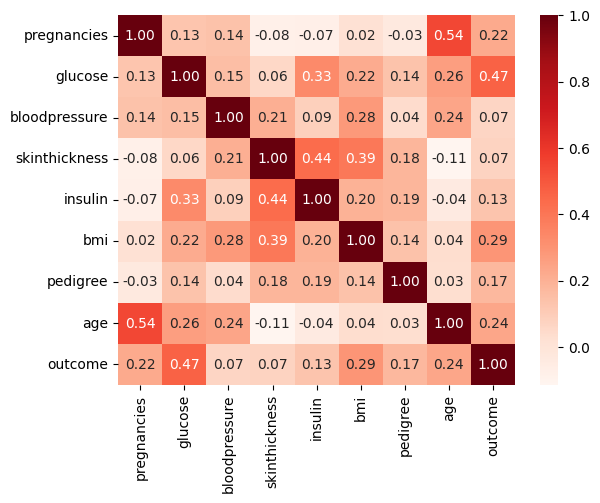

In [19]:
sns.heatmap(
                data = df.corr(),
                annot=True,
                fmt='.2f',
                cmap='Reds'
)
plt.show()

In [20]:
# The age column is correlated to pregnancies , we can try removing the column after training once to look for improvements.

In [25]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# Prepare your design matrix with the intercept added
X = add_constant(df.drop(columns=['outcome']))

# Calculate VIF for each column index in the matrix
vif_series = pd.Series([variance_inflation_factor(X.values, i) for i in range(X.shape[1])], index=X.columns)

vif_series

const            35.039974
pregnancies       1.430872
glucose           1.298961
bloodpressure     1.181863
skinthickness     1.507432
insulin           1.427536
bmi               1.297450
pedigree          1.067090
age               1.588368
dtype: float64

In [27]:
# As the values are below 5 we can use all the variables together as it has a unique contribution to the model somehow

In [51]:
X,y = df.drop(columns=['outcome']),df['outcome']

In [52]:
from sklearn.model_selection import train_test_split

# Pass your target column to the 'stratify' parameter
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    stratify=y,          # <-- This guarantees proportional splitting
    random_state=42
)

In [66]:
model = LogisticRegression(max_iter=1000,class_weight='balanced',C=0.1)
model.fit(X_train,y_train)
y_pred = model.predict(X_test)

In [67]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, X, y, cv=cv, scoring='f1')

scores

array([0.64347826, 0.73873874, 0.69491525, 0.63636364, 0.625     ])

In [68]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.82      0.75      0.79       100
           1       0.60      0.70      0.65        54

    accuracy                           0.73       154
   macro avg       0.71      0.73      0.72       154
weighted avg       0.75      0.73      0.74       154



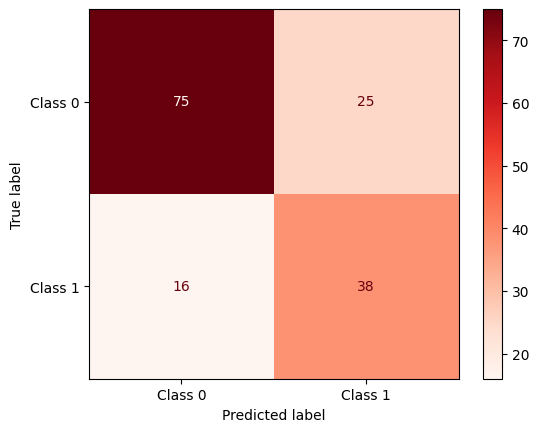

In [69]:
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test,y_pred), display_labels=['Class 0', 'Class 1'])
disp.plot(cmap="Reds")
plt.show()

In [63]:
# Our model is tending to misclassify a lot of the class 0 values as class 1

In [70]:
# NOW LET'S use random forest for any improvements

In [76]:
# 1. Initialize the Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42,max_depth=5, oob_score=True,class_weight='balanced')

# 2. Train the model
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [ ]:
# 3. Evaluate performance
y_pred = rf_model.predict(X_test)
print(f"OOB Score: {rf_model.oob_score_}\n")
print(classification_report(y_test, y_pred))

OOB Score: 0.749185667752443

              precision    recall  f1-score   support

           0       0.86      0.77      0.81       100
           1       0.64      0.76      0.69        54

    accuracy                           0.77       154
   macro avg       0.75      0.76      0.75       154
weighted avg       0.78      0.77      0.77       154



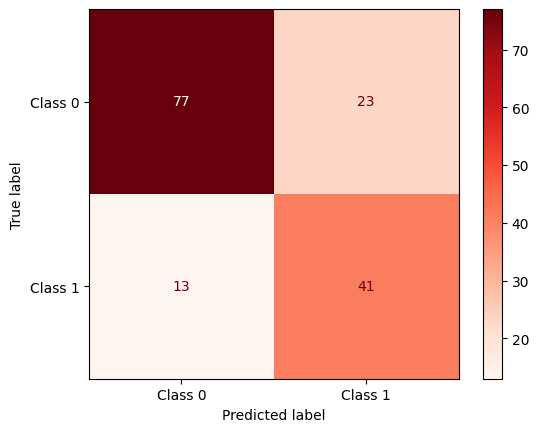

In [78]:
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test,y_pred), display_labels=['Class 0', 'Class 1'])
disp.plot(cmap="Reds")
plt.show()

In [ ]:
# Better results